In [2]:
# Steps -> Imports -> Dataloader -> transformation 

import os
import shutil
import random
import torch
import torchvision.transforms.v2 as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import datasets
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
from torch.utils.tensorboard import SummaryWriter
import torchvision.models as models

In [18]:
# Applying CutMix and MixUp

# transforms.RandomChoice works like a selector switch. 
# It takes a list of different transformations you give it, and every time a new batch passes through, 
# it randomly picks exactly one transformation from that list to apply, discarding the others for that turn.
# returns -> advanced_batch_augment(images, labels)
def apply_cut_mix_up():
    mixup = transforms.MixUp(alpha=0.2, num_classes=2) 
    cutmix = transforms.CutMix(alpha=1.0, num_classes=2)
    mix_choice = transforms.RandomChoice([mixup, cutmix])

    # Set probability to 50% so the model sees both clean and blended images
    return transforms.RandomApply([mix_choice], p=0.5)


def train_epoch(model, train_loader, optimizer, criterion, epoch, device, advanced_batch_augment=None):
    loss_list = []
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # =====================================================================
        # ADVANCED BATCH AUGMENTATION
        # =====================================================================
        # Apply CutMix or MixUp to the batch if the augmentation function is provided
        if advanced_batch_augment is not None:
            images, labels = advanced_batch_augment(images, labels)
        # =====================================================================
        
        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()
         
        # Forward pass to get output/logits
        outputs = model(images)
         
        # Calculate Loss (Handles both integer labels and soft probability matrices)
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())
         
        # Getting gradients w.r.t. parameters
        loss.backward()
        print(f"Raw Batch Loss: {loss.item()}")
         
        # Updating parameters
        optimizer.step()
        
    mean_loss = np.mean(loss_list)
    return mean_loss, loss_list


@torch.no_grad()
def eval_model(model, eval_loader, criterion, device):
    """ Evaluating the model for either validation or test (Strictly Clean Data) """
    correct = 0
    total = 0
    loss_list = []
    
    for images, labels in eval_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass only to get logits/output
        outputs = model(images)
                 
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())
            
        # Get predictions from the maximum value
        preds = torch.argmax(outputs, dim=1)
        correct += len(torch.where(preds == labels)[0])
        total += len(labels)
                 
    # Total correct predictions and loss
    accuracy = correct / total * 100
    loss = np.mean(loss_list)
    
    return accuracy, loss


def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs, device, tboard=None, start_epoch=0):
    """ Training a model for a given number of epochs with advanced augmentations """
    
    train_loss = []
    val_loss = []
    loss_iters = []
    valid_acc = []
    assert tboard is not None, f"Tensorboard must be provided!"
    
    # Initialize the reusable advanced batch augmentation selector
    advanced_batch_augment = apply_cut_mix_up()
    
    for epoch in tqdm(range(num_epochs)):
           
        # validation epoch
        model.eval()  # important for dropout and batch norms
        accuracy, loss = eval_model(
                    model=model, eval_loader=valid_loader,
                    criterion=criterion, device=device
            )
        valid_acc.append(accuracy)
        val_loss.append(loss)
        tboard.add_scalar(f'Accuracy/Valid', accuracy, global_step=epoch+start_epoch)
        tboard.add_scalar(f'Loss/Valid', loss, global_step=epoch+start_epoch)
        
        # training epoch
        model.train()  # important for dropout and batch norms
        mean_loss, cur_loss_iters = train_epoch(
                model=model, train_loader=train_loader, optimizer=optimizer,
                criterion=criterion, epoch=epoch, device=device,
                advanced_batch_augment=advanced_batch_augment  # Pass it down here
            )
        scheduler.step()
        train_loss.append(mean_loss)
        tboard.add_scalar(f'Loss/Train', mean_loss, global_step=epoch+start_epoch)

        loss_iters = loss_iters + cur_loss_iters
        
        if (epoch % 5 == 0 or epoch == num_epochs - 1):
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"    Train loss: {round(mean_loss, 5)}")
            print(f"    Valid loss: {round(loss, 5)}")
            print(f"    Accuracy: {accuracy}%")
            print("\n")
    
    print(f"Training completed")
    return train_loss, val_loss, loss_iters, valid_acc

In [4]:
def save_model(model, optimizer, epoch, stats):
    """ Saving model checkpoint """
    
    if(not os.path.exists("models")):
        os.makedirs("models")
    savepath = f"models/checkpoint_epoch_{epoch}.pth"

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'stats': stats
    }, savepath)
    return


def load_model(model, optimizer, savepath):
    """ Loading pretrained checkpoint """
    
    checkpoint = torch.load(savepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint["epoch"]
    stats = checkpoint["stats"]
    
    return model, optimizer, epoch, stats


def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f

def set_random_seed(random_seed=None):
    """
    Using random seed for numpy and torch
    """
    if(random_seed is None):
        random_seed = 13
    os.environ['PYTHONHASHSEED'] = str(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    return

In [5]:
# 1. Custom Gaussian Noise Transformation
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std
        
    def __call__(self, tensor):
        # Only add noise to the pixel data
        return tensor + torch.randn(tensor.size()) * self.std + self.mean
    
    
# 2. SEPARATE TRANSFORMS FOR TRAIN AND EVAL
data_transforms = {
    'train': transforms.Compose([
        transforms.ToImage(),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        
        # Added your requested augmentations
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        
        transforms.ToDtype(torch.float32, scale=True),
        AddGaussianNoise(mean=0.0, std=0.05),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.ToImage(),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [6]:
data_dir = '../data/assignment2'

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["train"])
valid_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), data_transforms["val"])

N_train = len(train_dataset)
N_valid = len(valid_dataset)
print(f"Training set size: {N_train} images")
print(f"Validation set size: {N_valid} images")

# Changed batch_size to 30 to evenly divide your 150 training images
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=30, shuffle=True, num_workers=4, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=30, shuffle=False, num_workers=4)

Training set size: 300 images
Validation set size: 60 images


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_training_progress(train_loss, val_loss, valid_acc):
    """ Plots training metrics side-by-side """
    plt.figure(figsize=(12, 5))
    
    # Left subplot: Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss', marker='o')
    plt.plot(val_loss, label='Valid Loss', marker='o')
    plt.title('Loss Progression')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Right subplot: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(valid_acc, label='Valid Accuracy', color='green', marker='s')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_progress.png')
    plt.show()


@torch.no_grad()
def generate_diagnostics(model, eval_loader, device, class_names=['person', 'robot']):
    """ Generates a confusion matrix and displays 5 correct and 5 wrong predictions """
    model.eval()
    all_preds = []
    all_labels = []
    
    correct_samples = []
    wrong_samples = []
    
    for images, labels in eval_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels_np = labels.numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels_np)
        
        # Track individual images for sample visualization
        for idx in range(len(labels_np)):
            img = images[idx]
            true_lbl = labels_np[idx]
            pred_lbl = preds[idx]
            
            if true_lbl == pred_lbl and len(correct_samples) < 5:
                correct_samples.append((img, true_lbl, pred_lbl))
            elif true_lbl != pred_lbl and len(wrong_samples) < 5:
                wrong_samples.append((img, true_lbl, pred_lbl))

    # --- 1. PLOT CONFUSION MATRIX ---
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Category')
    plt.xlabel('Predicted Category')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Helper to clean up image formatting for plotting
    def imshow_tensor(tensor_img, ax):
        # Reverse ImageNet normalization to show correct colors
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        np_img = tensor_img.numpy().transpose((1, 2, 0)) # CHW to HWC
        np_img = std * np_img + mean
        np_img = np.clip(np_img, 0, 1)
        ax.imshow(np_img)
        ax.axis('off')

    # --- 2. PLOT IMAGE SAMPLES ---
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Model Analysis: Top Row Correct | Bottom Row Misclassified', fontsize=16)
    
    # Plot top row: Correct predictions
    for idx, (img, true, pred) in enumerate(correct_samples):
        imshow_tensor(img, axes[0, idx])
        axes[0, idx].set_title(f"True/Pred: {class_names[true]}")
        
    # Plot bottom row: Missed predictions
    for idx, (img, true, pred) in enumerate(wrong_samples):
        imshow_tensor(img, axes[1, idx])
        axes[1, idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}", color='red')
        
    # Handle empty subplots if the model didn't hit exactly 5 errors
    for idx in range(len(wrong_samples), 5):
        axes[1, idx].axis('off')
        
    plt.tight_layout()
    plt.savefig('model_predictions_analysis.png')
    plt.show()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using execution device: {device}")

Using execution device: cuda


/home/user/ghietha1/miniforge3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/user/ghietha1/miniforge3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  4%|████▎                                                                                                      | 1/25 [00:03<01:31,  3.83s/it]

Epoch 1/25
    Train loss: 0.47727
    Valid loss: 0.67403
    Accuracy: 51.66666666666667%




 24%|█████████████████████████▋                                                                                 | 6/25 [00:21<01:06,  3.51s/it]

Epoch 6/25
    Train loss: 0.16941
    Valid loss: 0.20728
    Accuracy: 95.0%




 44%|██████████████████████████████████████████████▋                                                           | 11/25 [00:38<00:49,  3.53s/it]

...

Epoch 16/25
    Train loss: 0.24335
    Valid loss: 0.25635
    Accuracy: 88.33333333333333%




 84%|█████████████████████████████████████████████████████████████████████████████████████████                 | 21/25 [01:14<00:14,  3.61s/it]

Epoch 21/25
    Train loss: 0.14286
    Valid loss: 0.25072
    Accuracy: 90.0%




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:28<00:00,  3.55s/it]

Epoch 25/25
    Train loss: 0.11998
    Valid loss: 0.25652
    Accuracy: 88.33333333333333%


Training completed

Generating final visualization plots...


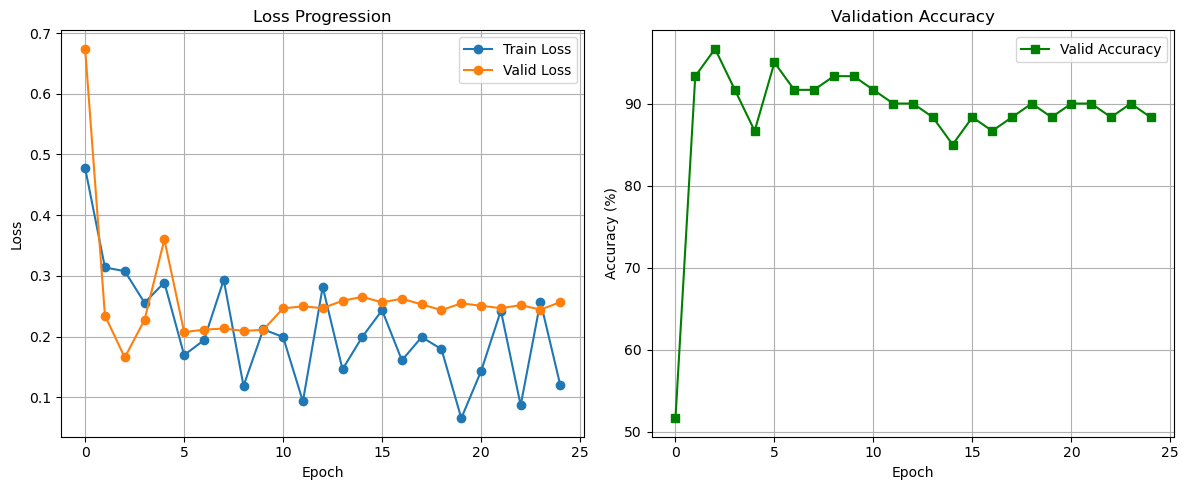

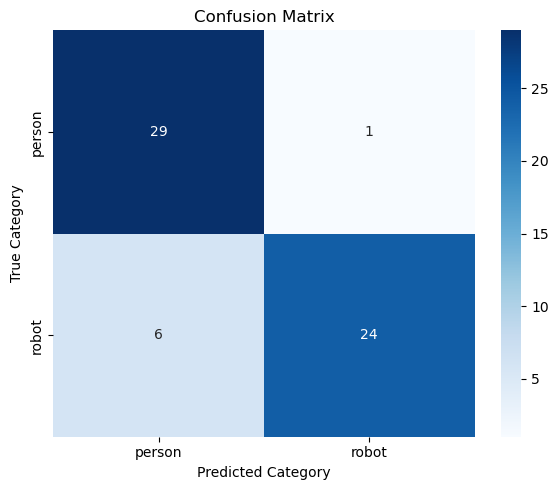

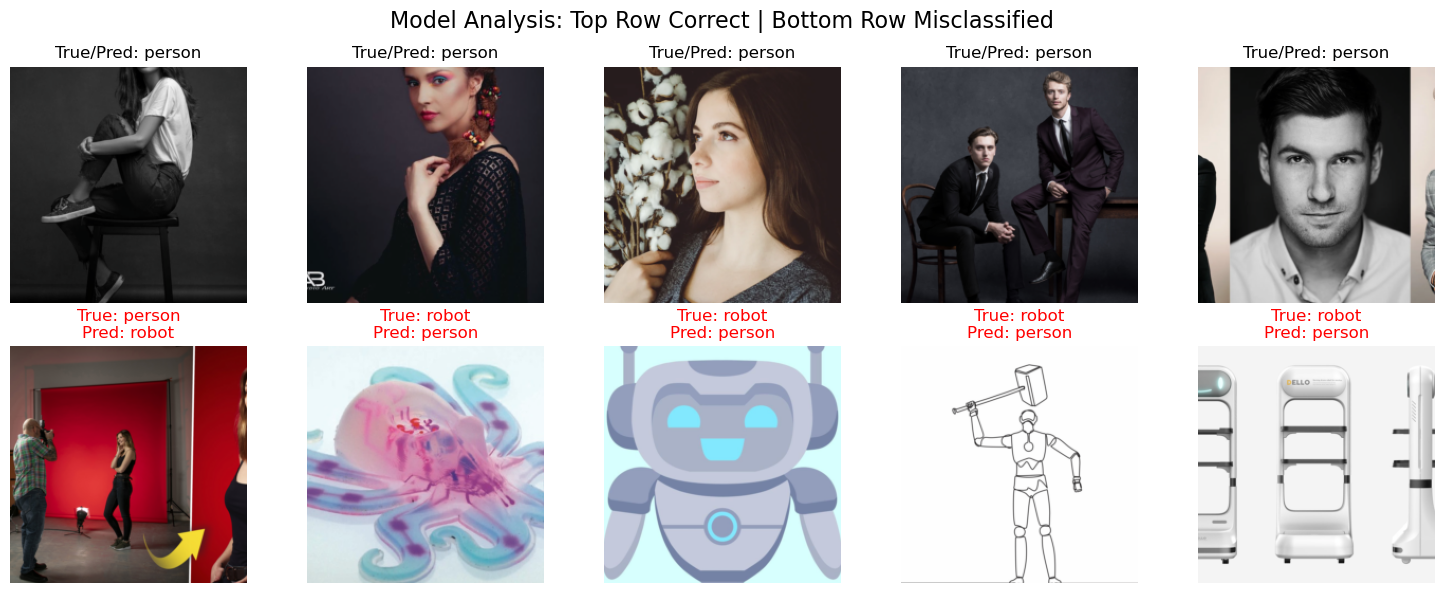

Diagnostics saved successfully as local images!


In [9]:
# resnet configuration

TBOARD_LOGS = os.path.join(os.getcwd(), "tboard_logs", "CNNs", "Resnet_fine_tuning")
if not os.path.exists(TBOARD_LOGS):
    os.makedirs(TBOARD_LOGS)

shutil.rmtree(TBOARD_LOGS)
writer = SummaryWriter(TBOARD_LOGS)

# Training and optimization
set_random_seed()

# downloading pretrained model
model = models.resnet18(pretrained=True)  # https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py

# replacing classification head with a single linear layer that outputs 2 logits
num_logits = model.fc.in_features
model.fc = nn.Sequential(
        nn.Linear(num_logits, 512),  # Maps from ResNet's 512 features to your hidden 512
        nn.ReLU(),
        nn.Dropout(0.2),              # Drops 20% of activations to combat overfitting
        nn.Linear(512, 2)   # Final projection layer out to your 2 logits
    )

model = model.to(device)


# classification loss function
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Decay LR by a factor of 3 every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=1/3) # used same config as tutorial


train_loss, val_loss, loss_iters, valid_acc = train_model(
        model=model, optimizer=optimizer, scheduler=scheduler, criterion=criterion,
        train_loader=train_loader, valid_loader=valid_loader, num_epochs=25, tboard=writer, device=device
    )

print("\nGenerating final visualization plots...")
    
# Plot loss curves and accuracy over time
plot_training_progress(train_loss, val_loss, valid_acc)

# Generate confusion matrix and show sample images
# Using valid_loader ensures you don't evaluate on CutMix/MixUp distorted samples
generate_diagnostics(model, valid_loader, device, class_names=['person', 'robot'])

print("Diagnostics saved successfully as local images!")

--- Loading Pre-trained ConvNeXt-Tiny ---


  4%|████▎                                                                                                      | 1/25 [00:03<01:34,  3.94s/it]

Epoch 1/25
    Train loss: 0.48437
    Valid loss: 0.68447
    Accuracy: 53.333333333333336%




 24%|█████████████████████████▋                                                                                 | 6/25 [00:24<01:19,  4.18s/it]

Epoch 6/25
    Train loss: 0.20898
    Valid loss: 0.09614
    Accuracy: 98.33333333333333%




...

Epoch 16/25
    Train loss: 0.17173
    Valid loss: 0.07593
    Accuracy: 98.33333333333333%




 84%|█████████████████████████████████████████████████████████████████████████████████████████                 | 21/25 [01:26<00:16,  4.13s/it]

Epoch 21/25
    Train loss: 0.06961
    Valid loss: 0.07806
    Accuracy: 98.33333333333333%




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:43<00:00,  4.13s/it]

Epoch 25/25
    Train loss: 0.18642
    Valid loss: 0.07708
    Accuracy: 98.33333333333333%


Training completed

Generating final visualization plots...


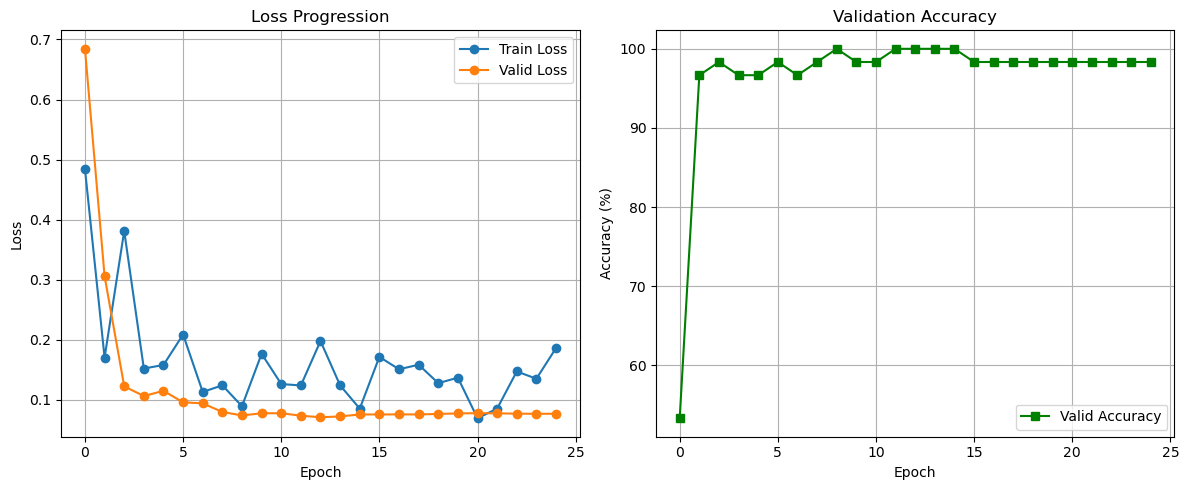

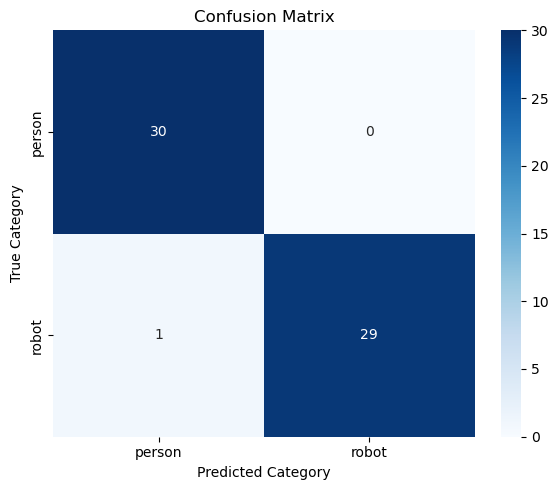

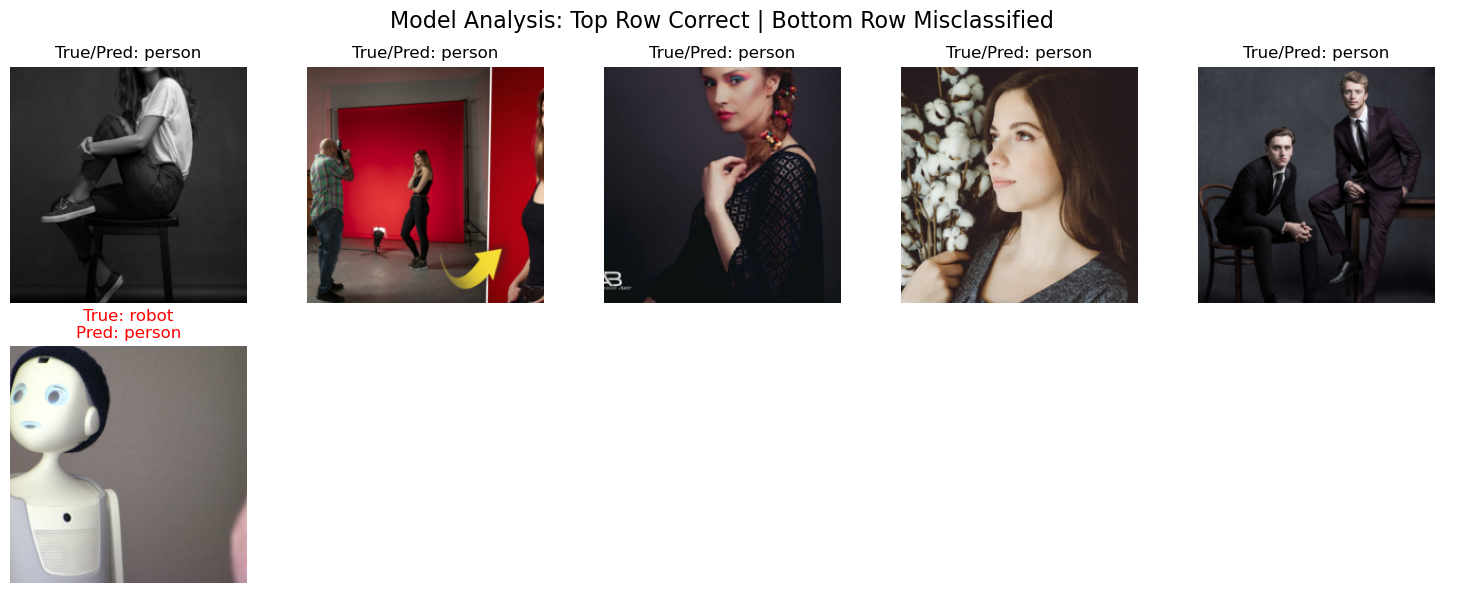

Diagnostics saved successfully as local images!


In [12]:
# Convnext 

print("--- Loading Pre-trained ConvNeXt-Tiny ---")
convnext_tiny_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# Map classifier projection block (index 2) to match 10 classes
in_features = convnext_tiny_model.classifier[2].in_features
convnext_tiny_model.classifier[2] = nn.Sequential(
        nn.Linear(in_features, 512),  # Maps from ResNet's 512 features to your hidden 512
        nn.ReLU(),
        nn.Dropout(0.2),              # Drops 20% of activations to combat overfitting
        nn.Linear(512, 2)   # Final projection layer out to your 2 logits
    )

convnext_tiny_model = convnext_tiny_model.to(device)


# classification loss function
convnext_tiny_criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
convnext_tiny_optimizer = torch.optim.Adam(convnext_tiny_model.parameters(), lr=1e-4)

# Decay LR by a factor of 3 every 5 epochs
convnext_tiny_scheduler = torch.optim.lr_scheduler.StepLR(convnext_tiny_optimizer, step_size=5, gamma=1/3) # used same config as tutorial

train_loss, val_loss, loss_iters, valid_acc = train_model(
        model=convnext_tiny_model, optimizer=convnext_tiny_optimizer, scheduler=convnext_tiny_scheduler, criterion=convnext_tiny_criterion,
        train_loader=train_loader, valid_loader=valid_loader, num_epochs=25, tboard=writer, device=device
    )

print("\nGenerating final visualization plots...")
    
# Plot loss curves and accuracy over time
plot_training_progress(train_loss, val_loss, valid_acc)

# Generate confusion matrix and show sample images
# Using valid_loader ensures you don't evaluate on CutMix/MixUp distorted samples
generate_diagnostics(convnext_tiny_model, valid_loader, device, class_names=['person', 'robot'])

print("Diagnostics saved successfully as local images!")

In [21]:
# Convnext 

print("--- Loading Pre-trained EfficientNet-B0 ---")
efficientnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Map classifier projection block (index 1) to match 10 classes
in_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Sequential(
        nn.Linear(in_features, 512),  # Maps from ResNet's 512 features to your hidden 512
        nn.ReLU(),
        nn.Dropout(0.2),              # Drops 20% of activations to combat overfitting
        nn.Linear(512, 2)   # Final projection layer out to your 2 logits
    )

efficientnet_model = efficientnet_model.to(device)


# classification loss function
efficientnet_criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
efficientnet_optimizer = torch.optim.Adam(efficientnet_model.parameters(), lr=1e-4)

# Decay LR by a factor of 3 every 5 epochs
efficientnet_scheduler = torch.optim.lr_scheduler.StepLR(efficientnet_optimizer, step_size=5, gamma=1/3) # used same config as tutorial

train_loss, val_loss, loss_iters, valid_acc = train_model(
        model=efficientnet_model, optimizer=efficientnet_optimizer, scheduler=efficientnet_scheduler, criterion=efficientnet_criterion,
        train_loader=train_loader, valid_loader=valid_loader, num_epochs=25, tboard=writer, device=device
    )

print("\nGenerating final visualization plots...")
    
# Plot loss curves and accuracy over time
plot_training_progress(train_loss, val_loss, valid_acc)

# Generate confusion matrix and show sample images
# Using valid_loader ensures you don't evaluate on CutMix/MixUp distorted samples
generate_diagnostics(efficientnet_model, valid_loader, device, class_names=['person', 'robot'])

print("Diagnostics saved successfully as local images!")

--- Loading Pre-trained EfficientNet-B0 ---


  0%|                                                                                                                   | 0/25 [00:00<?, ?it/s]

Raw Batch Loss: 0.6920002698898315
Raw Batch Loss: 0.6932860612869263
Raw Batch Loss: 0.6853142976760864
Raw Batch Loss: 0.7002975344657898
Raw Batch Loss: 0.6905770897865295
Raw Batch Loss: 0.6718961000442505
Raw Batch Loss: 0.663241982460022
Raw Batch Loss: 0.6294724941253662


  4%|████▎                                                                                                      | 1/25 [00:03<01:27,  3.66s/it]

Raw Batch Loss: 0.6179733872413635
Raw Batch Loss: 0.6336642503738403
Epoch 1/25
    Train loss: 0.66777
    Valid loss: 0.67155
    Accuracy: 61.66666666666667%


Raw Batch Loss: 0.6508719325065613
Raw Batch Loss: 0.6063650250434875
Raw Batch Loss: 0.5473687648773193
Raw Batch Loss: 0.5380159616470337
Raw Batch Loss: 0.5602402687072754
Raw Batch Loss: 0.5584626793861389
Raw Batch Loss: 0.4940130412578583
Raw Batch Loss: 0.454228937625885
Raw Batch Loss: 0.5810025930404663


...

Raw Batch Loss: 0.45796138048171997
Raw Batch Loss: 0.5066591501235962
Raw Batch Loss: 0.39599794149398804
Raw Batch Loss: 0.33159714937210083
Raw Batch Loss: 0.3638896644115448
Raw Batch Loss: 0.32108089327812195
Raw Batch Loss: 0.47187674045562744
Raw Batch Loss: 0.2693389058113098
Raw Batch Loss: 0.5272423028945923
Raw Batch Loss: 0.2998248040676117


 12%|████████████▊                                                                                              | 3/25 [00:10<01:18,  3.58s/it]

Raw Batch Loss: 0.5329000949859619


 12%|████████████▊                                                                                              | 3/25 [00:12<01:30,  4.11s/it]


KeyboardInterrupt: 

In [ ]:
efficientnet shows textbook extreme overfitting, the model is literally memorizing the training data, which is shown by the 0 loss in training.
This problem is caused by the massive model being used against a small dataset.

My next approach was to freeze the weights of network except for last FC layer. I also increased dropout to 0.5 

  0%|                                                                                                                   | 0/10 [00:00<?, ?it/s]

Raw Batch Loss: 0.7539957165718079
Raw Batch Loss: 0.6827431917190552
Raw Batch Loss: 0.6918734312057495
Raw Batch Loss: 0.6197955012321472
Raw Batch Loss: 0.6136074662208557
Raw Batch Loss: 0.5726827383041382
Raw Batch Loss: 0.5771682858467102
Raw Batch Loss: 0.6004590392112732


 10%|██████████▋                                                                                                | 1/10 [00:03<00:30,  3.41s/it]

Raw Batch Loss: 0.6160329580307007
Raw Batch Loss: 0.5868315696716309
Epoch 1/10
    Train loss: 0.63152
    Valid loss: 52.67848
    Accuracy: 41.66666666666667%


Raw Batch Loss: 0.5170145630836487
Raw Batch Loss: 0.4788946807384491
Raw Batch Loss: 0.4526614844799042
Raw Batch Loss: 0.44596847891807556
Raw Batch Loss: 0.5847472548484802
Raw Batch Loss: 0.4768684208393097
Raw Batch Loss: 0.5321875810623169
Raw Batch Loss: 0.37236687541007996


 20%|█████████████████████▍                                                                                     | 2/10 [00:06<00:26,  3.31s/it]

...

Raw Batch Loss: 0.38879498839378357
Raw Batch Loss: 0.23261161148548126
Raw Batch Loss: 0.6400047540664673
Raw Batch Loss: 0.3092185854911804
Raw Batch Loss: 0.47127699851989746
Raw Batch Loss: 0.23385097086429596
Raw Batch Loss: 0.1539439707994461
Raw Batch Loss: 0.1652923971414566
Raw Batch Loss: 0.1462387591600418


 90%|████████████████████████████████████████████████████████████████████████████████████████████████▎          | 9/10 [00:30<00:03,  3.40s/it]

Raw Batch Loss: 0.12510475516319275
Raw Batch Loss: 0.278180867433548
Raw Batch Loss: 0.17173144221305847
Raw Batch Loss: 0.20149454474449158
Raw Batch Loss: 0.1607060432434082
Raw Batch Loss: 0.41903290152549744
Raw Batch Loss: 0.20883765816688538
Raw Batch Loss: 0.15382003784179688
Raw Batch Loss: 0.20430251955986023
Raw Batch Loss: 0.1788804680109024
Raw Batch Loss: 0.5586020350456238
Raw Batch Loss: 0.6042498350143433


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:33<00:00,  3.35s/it]

Epoch 10/10
    Train loss: 0.28617
    Valid loss: 421.8447
    Accuracy: 48.333333333333336%


Training completed

Generating final visualization plots...


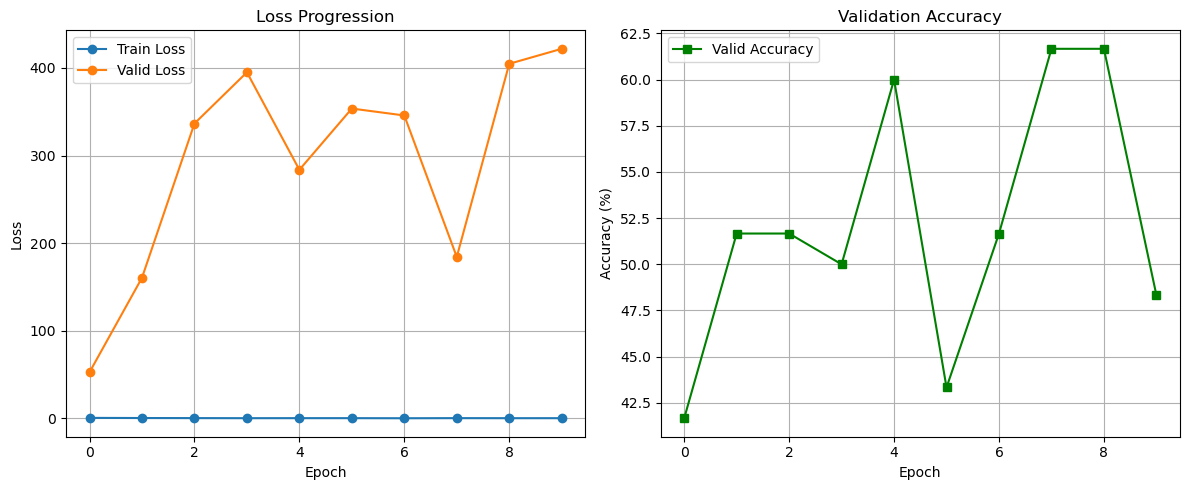

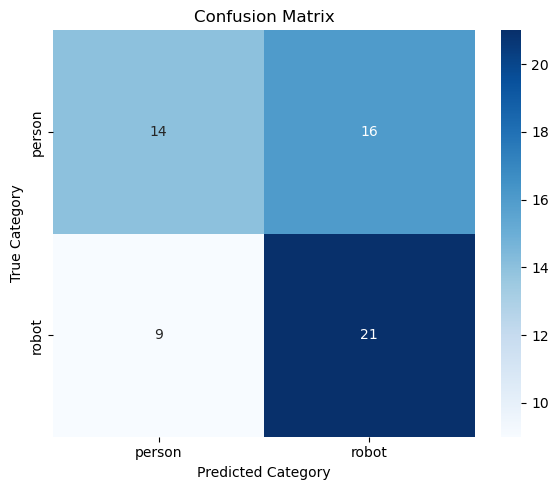

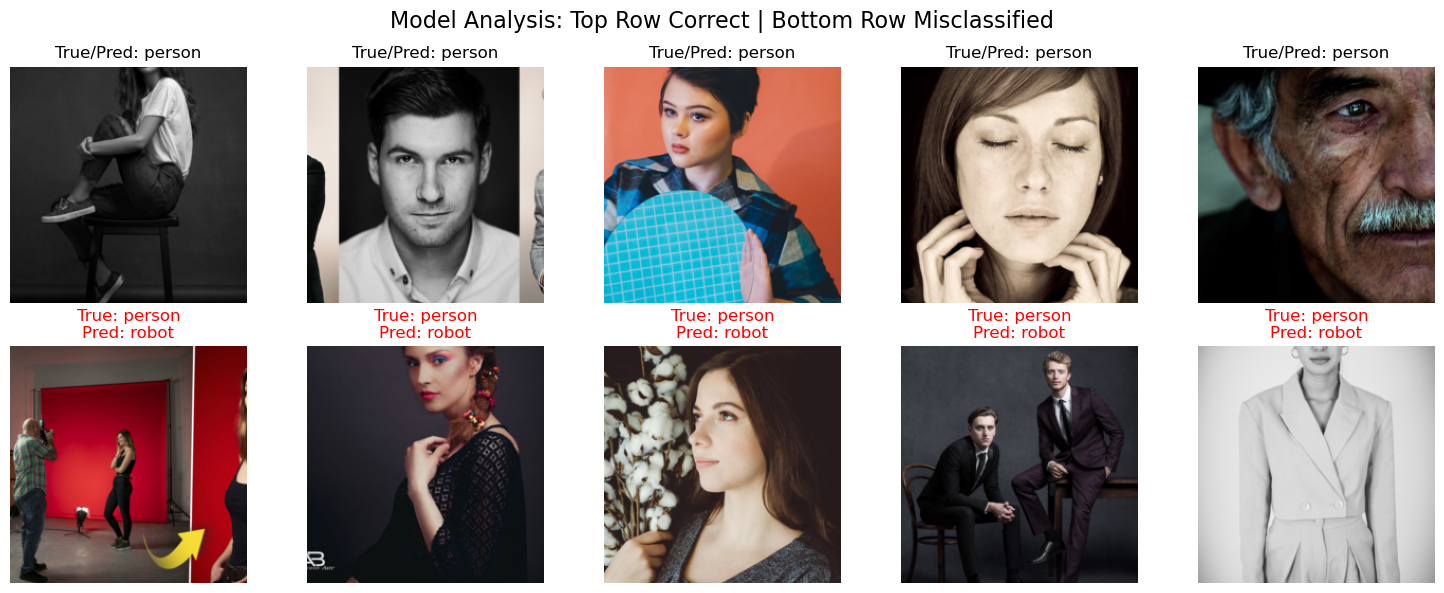

Diagnostics saved successfully as local images!


In [23]:
# Add this right after loading your model to freeze the layers
for param in efficientnet_model.parameters():
    param.requires_grad = False

# Then unfreeze ONLY your new classifier block so it learns
for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

efficientnet_model.classifier[1] = nn.Sequential(
        nn.Linear(in_features, 512),  # Maps from ResNet's 512 features to your hidden 512
        nn.ReLU(),
        nn.Dropout(0.5),              # Drops 20% of activations to combat overfitting
        nn.Linear(512, 2)   # Final projection layer out to your 2 logits
    )

efficientnet_model = efficientnet_model.to(device)


# classification loss function
efficientnet_criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
efficientnet_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, efficientnet_model.parameters()), lr=1e-4)

# Decay LR by a factor of 3 every 5 epochs
efficientnet_scheduler = torch.optim.lr_scheduler.StepLR(efficientnet_optimizer, step_size=5, gamma=1/3) # used same config as tutorial

train_loss, val_loss, loss_iters, valid_acc = train_model(
        model=efficientnet_model, optimizer=efficientnet_optimizer, scheduler=efficientnet_scheduler, criterion=efficientnet_criterion,
        train_loader=train_loader, valid_loader=valid_loader, num_epochs=10, tboard=writer, device=device
    )

print("\nGenerating final visualization plots...")
    
# Plot loss curves and accuracy over time
plot_training_progress(train_loss, val_loss, valid_acc)

# Generate confusion matrix and show sample images
# Using valid_loader ensures you don't evaluate on CutMix/MixUp distorted samples
generate_diagnostics(efficientnet_model, valid_loader, device, class_names=['person', 'robot'])

print("Diagnostics saved successfully as local images!")